In [ ]:
%reload_ext autoreload
%autoreload 2

from placefield_models import PlacefieldConfig, PlacefieldViewer

In [ ]:
cfg = PlacefieldConfig(
    n_neurons=8000,
    n_bins=100,
    normalize="peak",
    seed=0,
    tgp_amplitude=1.0,
    tgp_length_scale=0.6,
    tgp_threshold=0.25,
    tgp_periodic=True,
    pns_smooth_width=3.0,
    pns_alpha=1.5,
    pns_mean=0.0,
    pns_threshold=0.5,
    max_rate=10.0,
)
viewer = PlacefieldViewer(cfg)
viewer.show()

In [67]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

from my_precious_cvpca_simulation import (
    SimulationConfig,
    PlacefieldConfig,
    TilburyPlacefieldConfig,
    plot_placefields,
    run_simulations,
    plot_example_placefields,
)
from study_cvpca_vs_stimspace import (
    config_from_params,
    plot_best_spectra,
    plot_component_pair,
    plot_frac_neg_pair,
    plot_study,
    print_best_configs,
    run_full_simulations,
    run_study,
)

[autoreload of study_cvpca_vs_stimspace failed: Traceback (most recent call last):
  File "C:\Users\Andrew\AppData\Roaming\Python\Python311\site-packages\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "C:\Users\Andrew\AppData\Roaming\Python\Python311\site-packages\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\importlib\__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "c:\Users\Andrew\Documents\GitHub\vrAnalysis\study_cvpca_vs_stimspace.py", line 817, in <module>
    tilbury=TilburyPlacefieldConfig(
            ^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: TilburyPlac

In [153]:
# ============================================================
# CONFIGS — define all named configs here; edit/add as needed
# ============================================================

# --- RBF path ---
n_neurons = 500
n_positions = 100
n_repeats = 4
n_simulations = 20
n_components = 80

CFG_RBF_DEFAULT = SimulationConfig(
    placefield=PlacefieldConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        lengthscale=8.0,
        threshold_pct=60.0,
        amplitude=10.0,
        repeat_noise_alpha=0.3,
        repeat_noise_lengthscale=5.0,
    ),
    noise_level=1.0,
    n_repeats=n_repeats,
    normalize=True,
    center=True,
    smooth_width=3.0,
    n_components=n_components,
    n_simulations=n_simulations,
    seed=42,
    generation_path="rbf",
)

# best params from a prior optuna run
CFG_RBF_OPTUNA = SimulationConfig(
    placefield=PlacefieldConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        lengthscale=18.59,
        threshold_pct=28.8,
        amplitude=3.69,
        repeat_noise_alpha=0.32,
        repeat_noise_lengthscale=1.18,
        peak_exponent=1.92,
        peak_sigma_scale=2.76,
    ),
    noise_level=0.20,
    n_repeats=n_repeats,
    normalize=True,
    center=False,
    smooth_width=0.83,
    n_components=n_components,
    n_simulations=n_simulations,
    seed=42,
    generation_path="rbf",
)

# --- Tilbury path ---

# strict: near single symmetric gaussian (large amplitude_ratio_beta, p=2, no asym)
CFG_TILBURY_STRICT = SimulationConfig(
    placefield=PlacefieldConfig(n_neurons=n_neurons, n_positions=n_positions),
    tilbury=TilburyPlacefieldConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        amplitude_mean=10.0,
        amplitude_spread=0.3,
        amplitude_ratio_beta=20.0,  # near single-bump
        peak_separation_scale=10.0,
        sigma_mean=8.0,
        sigma_spread=0.2,
        sigma_asym_std=0.0,  # symmetric
        exponent_mean=2.0,
        exponent_spread=0.0,  # standard gaussian
        repeat_noise_alpha=0.3,
        repeat_noise_lengthscale=5.0,
        repeat_noise_threshold_pct=60.0,
    ),
    noise_level=1.0,
    n_repeats=n_repeats,
    normalize=True,
    center=True,
    smooth_width=3.0,
    n_components=n_components,
    n_simulations=n_simulations,
    seed=42,
    generation_path="tilbury",
)

# free: double asymmetric generalized gaussian, variable exponent
CFG_TILBURY_FREE = SimulationConfig(
    placefield=PlacefieldConfig(n_neurons=n_neurons, n_positions=n_positions),
    tilbury=TilburyPlacefieldConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        amplitude_mean=10.0,
        amplitude_spread=0.5,
        amplitude_ratio_beta=2.0,  # allow strong second bump
        peak_separation_scale=25.0,
        sigma_mean=8.0,
        sigma_spread=0.5,
        sigma_asym_std=0.8,  # asymmetric sigma
        exponent_mean=2.0,
        exponent_spread=0.5,  # variable exponent across neurons
        repeat_noise_alpha=0.3,
        repeat_noise_lengthscale=5.0,
        repeat_noise_threshold_pct=60.0,
    ),
    noise_level=1.0,
    n_repeats=n_repeats,
    normalize=True,
    center=True,
    smooth_width=3.0,
    n_components=n_components,
    n_simulations=n_simulations,
    seed=42,
    generation_path="tilbury",
)

# optuna: double asymmetric generalized gaussian, using optuna params
CFG_TILBURY_OPTUNA = SimulationConfig(
    placefield=PlacefieldConfig(n_neurons=n_neurons, n_positions=n_positions),
    tilbury=TilburyPlacefieldConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        amplitude_mean=18.0,
        amplitude_spread=0.02,
        amplitude_ratio_beta=37.5,
        peak_separation_scale=50.0,
        sigma_mean=16.0,
        sigma_spread=0.33,
        sigma_asym_std=1.33,  # asymmetric sigma
        exponent_mean=2.25,
        exponent_spread=0.5,  # variable exponent across neurons
        repeat_noise_alpha=0.45,
        repeat_noise_lengthscale=1.0,
        repeat_noise_threshold_pct=20.0,
    ),
    noise_level=0.002,
    n_repeats=n_repeats,
    normalize=False,
    center=False,
    smooth_width=0.75,
    n_components=n_components,
    n_simulations=n_simulations,
    seed=42,
    generation_path="tilbury",
)

In [69]:
# ============================================================
# ACTIVE CONFIG — change this to switch paths for cells below
# ============================================================
ACTIVE_CFG = CFG_TILBURY_OPTUNA
N_SIMS = 20
DEVICE = "cpu"

# configs to compare in the comparison section at the bottom
COMPARE_CFGS = {
    "rbf_default": CFG_RBF_DEFAULT,
    "tilbury_strict": CFG_TILBURY_STRICT,
    "tilbury_free": CFG_TILBURY_FREE,
}

print(f"Active path: {ACTIVE_CFG.generation_path}")

Active path: tilbury


## Section 1: run_simulations (neuron vs position cvPCA)

In [243]:
cfg_s1 = replace(ACTIVE_CFG, n_simulations=N_SIMS)
print(f"Running {N_SIMS} simulations (path={cfg_s1.generation_path})...")
base_result = run_simulations(cfg_s1, device=DEVICE)
print(f"  burn_in={base_result['burn_in']}")
for key, label in [("frac_neg_cov_neuron", "neuron  "), ("frac_neg_cov_position", "position")]:
    fn = base_result[key]
    d40, d79 = min(39, len(fn) - 1), min(78, len(fn) - 1)
    print(f"  {label} frac<0 @dim{d40+1}/dim{d79+1}: {fn[d40]:.2f} / {fn[d79]:.2f}")

Running 20 simulations (path=tilbury)...


  burn_in=4
  neuron   frac<0 @dim40/dim79: 0.00 / 0.00
  position frac<0 @dim40/dim79: 0.00 / 0.00


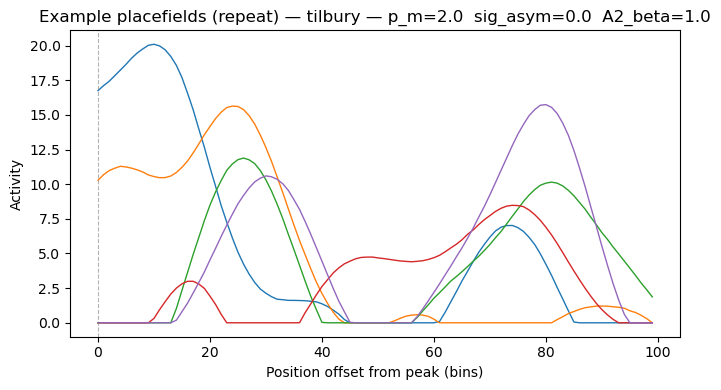

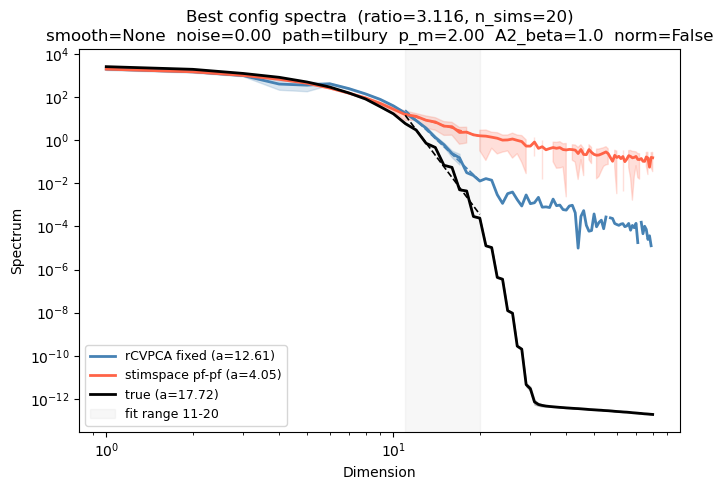

full simulations: 100%|██████████| 10/10 [00:00<00:00, 29.89it/s]


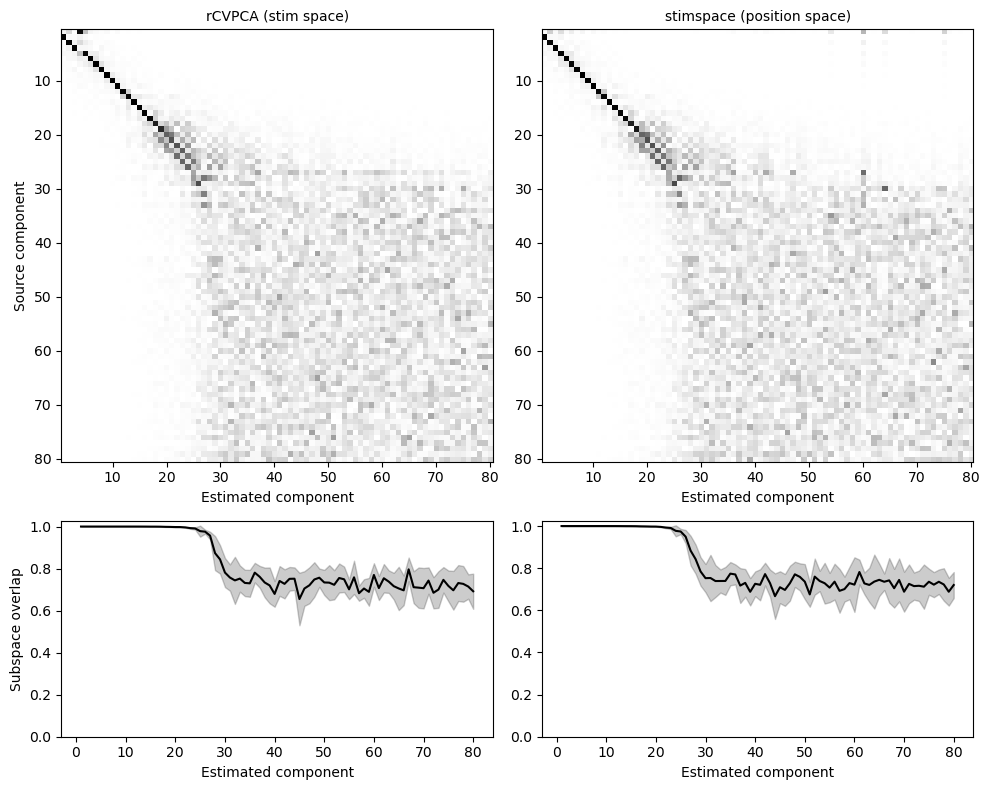

In [238]:
# ACTIVE_CFG = SimulationConfig(
#     placefield=PlacefieldConfig(n_neurons=n_neurons, n_positions=n_positions),
#     tilbury=TilburyPlacefieldConfig(
#         n_neurons=n_neurons,
#         n_positions=n_positions,
#         amplitude_mean=10.0,
#         amplitude_spread=0.0,
#         amplitude_ratio_beta=1.0,
#         peak_separation_scale=50.0,
#         sigma_mean=8.0,
#         sigma_spread=0.0,
#         sigma_asym_std=0.0,  # asymmetric sigma
#         exponent_mean=1.5,
#         exponent_spread=0.0,  # variable exponent across neurons
#         repeat_noise_alpha=0.5,
#         repeat_noise_lengthscale=2.0,
#         repeat_noise_threshold_pct=5.0,
#     ),
#     noise_level=0.002,
#     n_repeats=n_repeats,
#     normalize=False,
#     center=True,
#     smooth_width=2.5,
#     n_components=n_components,
#     n_simulations=n_simulations,
#     seed=43,
#     generation_path="tilbury",
# )

DIFFERENTIAL_SIMPLE_CFG = SimulationConfig(
    placefield=PlacefieldConfig(n_neurons=n_neurons, n_positions=n_positions),
    tilbury=TilburyPlacefieldConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        amplitude_mean=10.0,
        amplitude_spread=0.0,
        amplitude_ratio_beta=1.0,
        peak_separation_scale=20.0,
        sigma_mean=10.0,
        sigma_spread=0.0,
        sigma_asym_std=0.0,  # asymmetric sigma
        exponent_mean=1.0,
        exponent_spread=0.0,  # variable exponent across neurons
        repeat_noise_alpha=0.5,
        repeat_noise_lengthscale=2.0,
        repeat_noise_threshold_pct=5.0,
    ),
    noise_level=0.000,
    n_repeats=n_repeats,
    normalize=False,
    center=True,
    smooth_width=1.0,
    n_components=n_components,
    n_simulations=n_simulations,
    seed=43,
    generation_path="tilbury",
)

NODIFFERENTIAL_SIMPLE_CFG = SimulationConfig(
    placefield=PlacefieldConfig(n_neurons=n_neurons, n_positions=n_positions),
    tilbury=TilburyPlacefieldConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        amplitude_mean=10.0,
        amplitude_spread=0.0,
        amplitude_ratio_beta=1.0,
        peak_separation_scale=20.0,
        sigma_mean=10.0,
        sigma_spread=0.0,
        sigma_asym_std=0.0,  # asymmetric sigma
        exponent_mean=2.0,
        exponent_spread=0.0,  # variable exponent across neurons
        repeat_noise_alpha=5.0,
        repeat_noise_lengthscale=18.0,
        repeat_noise_threshold_pct=30.0,
    ),
    noise_level=0.000,
    n_repeats=n_repeats,
    normalize=False,
    center=True,
    smooth_width=None,
    n_components=n_components,
    n_simulations=n_simulations,
    seed=43,
    generation_path="tilbury",
)


# best params from a prior optuna run
CFG_RBF_OPTUNA = SimulationConfig(
    placefield=PlacefieldConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        lengthscale=18.0,
        threshold_pct=30.0,
        amplitude=4.0,
        repeat_noise_alpha=0.0,
        repeat_noise_lengthscale=1.0,
        peak_exponent=2.0,
        peak_sigma_scale=100000,
    ),
    noise_level=0.0,
    n_repeats=n_repeats,
    normalize=True,
    center=False,
    smooth_width=None,
    n_components=n_components,
    n_simulations=n_simulations,
    seed=42,
    generation_path="rbf",
)

plot_example_placefields(NODIFFERENTIAL_SIMPLE_CFG, num_examples=5, normalize=False, center_align=False, with_noise=True)
plt.show()

plot_best_spectra(NODIFFERENTIAL_SIMPLE_CFG, n_sims=N_SIMS, device=DEVICE, start_dim=10, end_dim=20)
plt.show()

plot_component_pair(NODIFFERENTIAL_SIMPLE_CFG, n_show=80, n_sims=10, device=DEVICE)
plt.show()

## Section 2: rCVPCA vs stimspace — Optuna study

In [71]:
N_TRIALS = 200
N_SIMS_PER_TRIAL = 20
OPTUNA_SEED = 0

base_study = replace(ACTIVE_CFG, n_simulations=N_SIMS_PER_TRIAL)

print(f"Running Optuna study: {N_TRIALS} trials x {N_SIMS_PER_TRIAL} sims  path={base_study.generation_path}")
study = run_study(base_study, n_trials=N_TRIALS, n_sims_per_trial=N_SIMS_PER_TRIAL, device=DEVICE, seed=OPTUNA_SEED)
print_best_configs(study, top_n=5)

Running Optuna study: 200 trials x 20 sims  path=tilbury


  0%|          | 0/200 [00:00<?, ?it/s]

c:\Users\Andrew\Documents\GitHub\vrAnalysis\dimilibi\helpers.py:429: RuntimeWarning:

invalid value encountered in log




=== Top 5 configs by alpha_cvpca/alpha_stim ratio ===
#1  ratio=6.6304  trial=125  alpha_cvpca=3.649  alpha_stim=0.643
    amp_m=17.27  amp_s=0.02  A2_beta=37.50  sep=49.98
    sig_m=16.66  sig_s=0.33  sig_asym=1.33  p_m=2.27  p_s=0.52
    rep_a=0.45  rep_ls=1.06  rep_thr=20.0  noise=0.002  smooth=0.75  norm=False  center=False
#2  ratio=6.5411  trial=191  alpha_cvpca=3.615  alpha_stim=0.582
    amp_m=15.54  amp_s=0.33  A2_beta=42.77  sep=8.32
    sig_m=15.50  sig_s=0.30  sig_asym=1.39  p_m=2.41  p_s=0.48
    rep_a=0.48  rep_ls=1.11  rep_thr=6.6  noise=0.005  smooth=0.65  norm=True  center=False
#3  ratio=6.3143  trial=161  alpha_cvpca=3.757  alpha_stim=0.485
    amp_m=15.49  amp_s=0.12  A2_beta=36.86  sep=46.48
    sig_m=15.41  sig_s=0.18  sig_asym=1.35  p_m=2.34  p_s=0.51
    rep_a=0.53  rep_ls=1.20  rep_thr=9.0  noise=0.002  smooth=0.56  norm=True  center=False
#4  ratio=6.1603  trial=120  alpha_cvpca=3.574  alpha_stim=0.638
    amp_m=20.08  amp_s=0.01  A2_beta=41.92  sep=49.88
   

In [73]:
figs = plot_study(study)
figs["history"].show()
figs["parallel"].show()

In [74]:
cfg_best = config_from_params(study.best_trial.params, base_study)
print(f"Best config  ratio={study.best_trial.value:.4f}  path={cfg_best.generation_path}")
for k, v in study.best_trial.params.items():
    print(f"  {k}={v}")

stacked = run_full_simulations(cfg_best, n_sims=N_SIMS, device=DEVICE)
print(f"\nMedian ratio:    {np.median(stacked['ratio']):.3f}")
print(f"Mean ratio:      {stacked['ratio'].mean():.3f} +/- {stacked['ratio'].std():.3f}")
print(f"Mean alpha_cv:   {stacked['alpha_cvpca'].mean():.3f}")
print(f"Mean alpha_stim: {stacked['alpha_stim'].mean():.3f}")

Best config  ratio=6.6304  path=tilbury
  tb_amplitude_mean=17.268069269426594
  tb_amplitude_spread=0.024748276600885848
  tb_amplitude_ratio_beta=37.49695695848314
  tb_peak_separation_scale=49.98360389435175
  tb_sigma_mean=16.655908681776147
  tb_sigma_spread=0.32819811384792724
  tb_sigma_asym_std=1.3267267568396108
  tb_exponent_mean=2.266770461412337
  tb_exponent_spread=0.5173807712142029
  tb_repeat_noise_alpha=0.4491329823709233
  tb_repeat_noise_lengthscale=1.0632817190418646
  tb_repeat_noise_threshold_pct=19.967489840489073
  smooth=True
  smooth_width=0.7524578544875025
  noise_level=0.0021801397251344375
  normalize=False
  center=False


full simulations: 100%|██████████| 20/20 [00:00<00:00, 25.04it/s]


Median ratio:    1.207
Mean ratio:      1.202 +/- 0.127
Mean alpha_cv:   3.649
Mean alpha_stim: 3.066


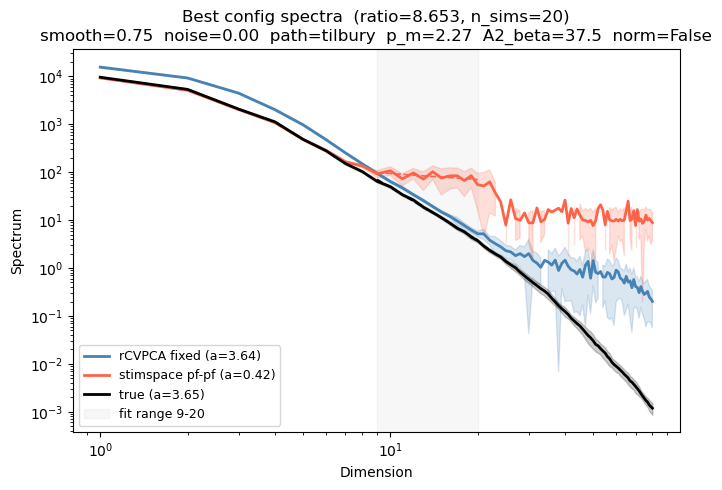

In [75]:
# Spectra: best optuna config
plot_best_spectra(cfg_best, n_sims=N_SIMS, device=DEVICE)
plt.show()

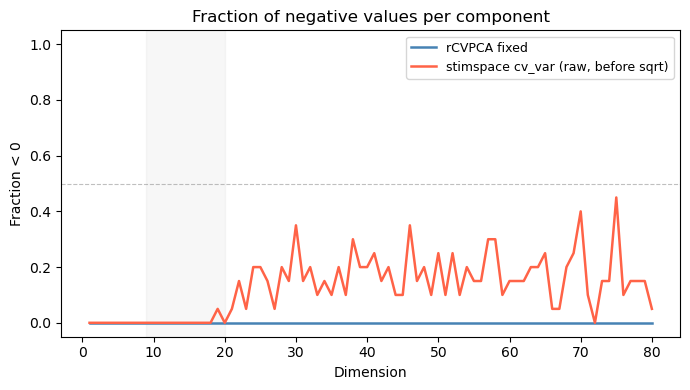

In [76]:
# Fraction of negatives
plot_frac_neg_pair(stacked)
plt.show()

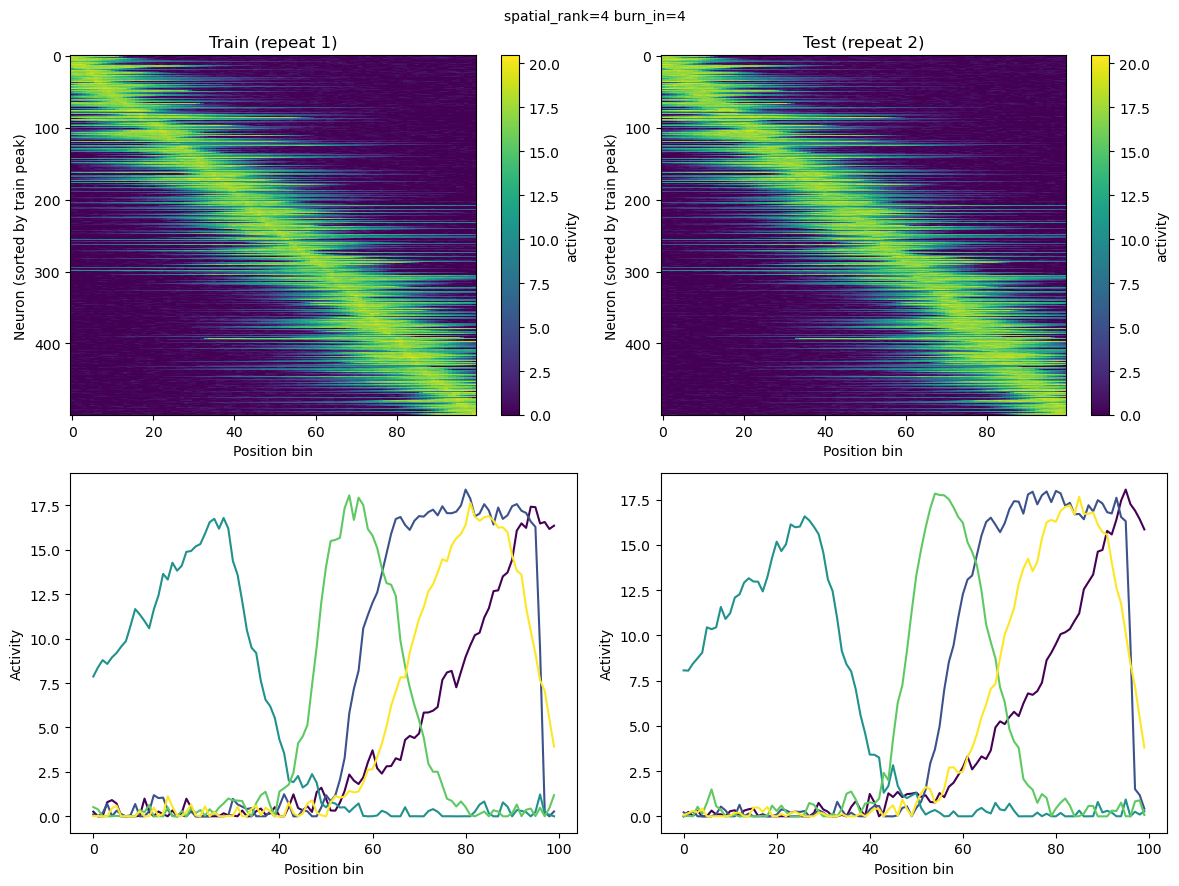

In [79]:
# Sorted placefield heatmaps for the active config
plot_placefields(cfg_best, device=DEVICE)
plt.show()

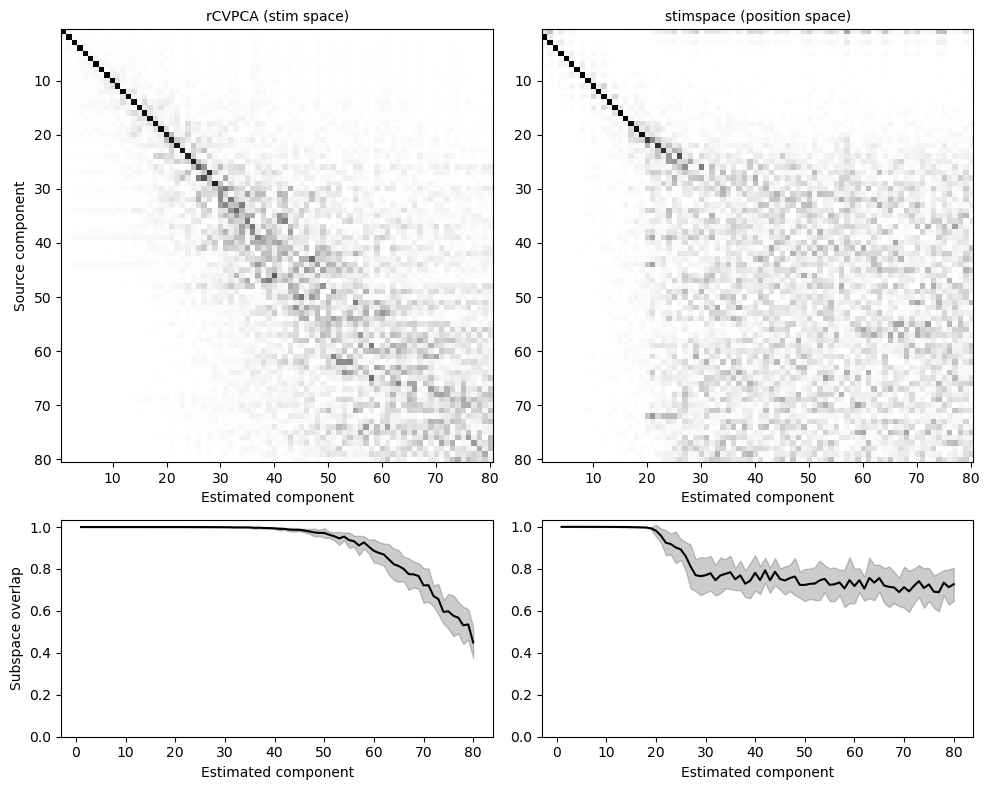

In [80]:
# Component comparison: rCVPCA (neuron space) and stimspace (position space) vs source SVD
plot_component_pair(stacked, n_show=80)
plt.show()

## Section 3: Multi-config comparison (uses COMPARE_CFGS defined at top)

In [ ]:
# Run full simulations for each config in COMPARE_CFGS
compare_stacked = {}
for label, cfg in COMPARE_CFGS.items():
    cfg_run = replace(cfg, n_simulations=N_SIMS)
    print(f"Running '{label}'  path={cfg_run.generation_path}...")
    compare_stacked[label] = run_full_simulations(cfg_run, n_sims=N_SIMS, device=DEVICE)
    s = compare_stacked[label]
    print(f"  median_ratio={np.median(s['ratio']):.3f}  alpha_cv={s['alpha_cvpca'].mean():.3f}  alpha_stim={s['alpha_stim'].mean():.3f}")

In [ ]:
# Spectra comparison: one plot per config
for label, cfg in COMPARE_CFGS.items():
    cfg_run = replace(cfg, n_simulations=N_SIMS)
    fig = plot_best_spectra(cfg_run, n_sims=N_SIMS, device=DEVICE)
    fig.suptitle(f"{label}  ({cfg_run.generation_path})", fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
# Placefield heatmaps for each config
for label, cfg in COMPARE_CFGS.items():
    fig = plot_placefields(cfg, device=DEVICE)
    fig.suptitle(label, fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
# Fraction-negative comparison
fig, axes = plt.subplots(1, len(compare_stacked), figsize=(5 * len(compare_stacked), 4), squeeze=False)
for ax, (label, s) in zip(axes[0], compare_stacked.items()):
    n_comp = s["reg_cov"].shape[1]
    dims = np.arange(1, n_comp + 1)
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.plot(dims, s["frac_neg_reg_cov"], color="steelblue", lw=1.8, label="rCVPCA")
    ax.plot(dims, s["frac_neg_cv_var_raw"], color="tomato", lw=1.8, label="stimspace")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Dimension")
    ax.legend(fontsize=8)
axes[0][0].set_ylabel("Fraction < 0")
plt.suptitle("Fraction negative per component", fontsize=11)
plt.tight_layout()
plt.show()

## New API: dimensionality_manuscript.simulations (placefield_generator + placefield_analysis)

Equivalent workflow using the new modules. Key API differences vs the old scripts:
- `SimulationConfig` → `SimConfig`; `TilburyPlacefieldConfig` → `TilburyConfig`
- `SimConfig(generator=PlacefieldConfig(...)|TilburyConfig(...), ...)` — no `generation_path`, `n_simulations`, separate `tilbury` field
- `run_simulations(cfg)` → `run_neuron_position(cfg, n_sims)`
- `run_full_simulations(cfg, n_sims)` → `run_cvpca_stimspace_stack(cfg, n_sims)`
- `plot_best_spectra` → `plot_spectra`; `plot_component_pair` → `plot_component_alignment`; `plot_frac_neg_pair` → `plot_frac_neg`

In [239]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

from dimensionality_manuscript.simulations.placefield_generator import (
    SimConfig, PlacefieldConfig, TilburyConfig,
)
from dimensionality_manuscript.simulations.placefield_analysis import (
    config_from_params,
    plot_component_alignment,
    plot_example_placefields,
    plot_frac_neg,
    plot_neuron_position,
    plot_placefields,
    plot_spectra,
    plot_study,
    print_best_configs,
    run_cvpca_stimspace_stack,
    run_neuron_position,
    run_study,
)

In [240]:
# ============================================================
# CONFIGS (new API) — mirrors the old SimulationConfig blocks above
# ============================================================

n_neurons = 500
n_positions = 100
n_repeats = 4
n_components = 80

NEW_CFG_RBF_DEFAULT = SimConfig(
    generator=PlacefieldConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        lengthscale=8.0,
        threshold_pct=60.0,
        amplitude=10.0,
        repeat_noise_alpha=0.3,
        repeat_noise_lengthscale=5.0,
    ),
    noise_level=1.0,
    n_repeats=n_repeats,
    normalize=True,
    center=True,
    smooth_width=3.0,
    n_components=n_components,
    seed=42,
)

NEW_CFG_RBF_OPTUNA = SimConfig(
    generator=PlacefieldConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        lengthscale=18.59,
        threshold_pct=28.8,
        amplitude=3.69,
        repeat_noise_alpha=0.32,
        repeat_noise_lengthscale=1.18,
        peak_exponent=1.92,
        peak_sigma_scale=2.76,
    ),
    noise_level=0.20,
    n_repeats=n_repeats,
    normalize=True,
    center=False,
    smooth_width=0.83,
    n_components=n_components,
    seed=42,
)

NEW_CFG_TILBURY_STRICT = SimConfig(
    generator=TilburyConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        amplitude_mean=10.0,
        amplitude_spread=0.3,
        amplitude_ratio_beta=20.0,
        peak_separation_scale=10.0,
        sigma_mean=8.0,
        sigma_spread=0.2,
        sigma_asym_std=0.0,
        exponent_mean=2.0,
        exponent_spread=0.0,
        repeat_noise_alpha=0.3,
        repeat_noise_lengthscale=5.0,
        repeat_noise_threshold_pct=60.0,
    ),
    noise_level=1.0,
    n_repeats=n_repeats,
    normalize=True,
    center=True,
    smooth_width=3.0,
    n_components=n_components,
    seed=42,
)

NEW_CFG_TILBURY_FREE = SimConfig(
    generator=TilburyConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        amplitude_mean=10.0,
        amplitude_spread=0.5,
        amplitude_ratio_beta=2.0,
        peak_separation_scale=25.0,
        sigma_mean=8.0,
        sigma_spread=0.5,
        sigma_asym_std=0.8,
        exponent_mean=2.0,
        exponent_spread=0.5,
        repeat_noise_alpha=0.3,
        repeat_noise_lengthscale=5.0,
        repeat_noise_threshold_pct=60.0,
    ),
    noise_level=1.0,
    n_repeats=n_repeats,
    normalize=True,
    center=True,
    smooth_width=3.0,
    n_components=n_components,
    seed=42,
)

NEW_CFG_TILBURY_OPTUNA = SimConfig(
    generator=TilburyConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        amplitude_mean=18.0,
        amplitude_spread=0.02,
        amplitude_ratio_beta=37.5,
        peak_separation_scale=50.0,
        sigma_mean=16.0,
        sigma_spread=0.33,
        sigma_asym_std=1.33,
        exponent_mean=2.25,
        exponent_spread=0.5,
        repeat_noise_alpha=0.45,
        repeat_noise_lengthscale=1.0,
        repeat_noise_threshold_pct=20.0,
    ),
    noise_level=0.002,
    n_repeats=n_repeats,
    normalize=False,
    center=False,
    smooth_width=0.75,
    n_components=n_components,
    seed=42,
)

NEW_DIFFERENTIAL_SIMPLE_CFG = SimConfig(
    generator=TilburyConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        amplitude_mean=10.0,
        amplitude_spread=0.0,
        amplitude_ratio_beta=1.0,
        peak_separation_scale=20.0,
        sigma_mean=10.0,
        sigma_spread=0.0,
        sigma_asym_std=0.0,
        exponent_mean=1.0,
        exponent_spread=0.0,
        repeat_noise_alpha=0.5,
        repeat_noise_lengthscale=2.0,
        repeat_noise_threshold_pct=5.0,
    ),
    noise_level=0.0,
    n_repeats=n_repeats,
    normalize=False,
    center=True,
    smooth_width=1.0,
    n_components=n_components,
    seed=43,
)

NEW_NODIFFERENTIAL_SIMPLE_CFG = SimConfig(
    generator=TilburyConfig(
        n_neurons=n_neurons,
        n_positions=n_positions,
        amplitude_mean=10.0,
        amplitude_spread=0.0,
        amplitude_ratio_beta=1.0,
        peak_separation_scale=20.0,
        sigma_mean=10.0,
        sigma_spread=0.0,
        sigma_asym_std=0.0,
        exponent_mean=2.0,
        exponent_spread=0.0,
        repeat_noise_alpha=5.0,
        repeat_noise_lengthscale=18.0,
        repeat_noise_threshold_pct=30.0,
    ),
    noise_level=0.0,
    n_repeats=n_repeats,
    normalize=False,
    center=True,
    smooth_width=None,
    n_components=n_components,
    seed=43,
)

In [241]:
# ============================================================
# ACTIVE CONFIG — change this to switch for cells below
# ============================================================
NEW_ACTIVE_CFG = NEW_CFG_TILBURY_OPTUNA
N_SIMS = 20
DEVICE = "cpu"

NEW_COMPARE_CFGS = {
    "rbf_default": NEW_CFG_RBF_DEFAULT,
    "tilbury_strict": NEW_CFG_TILBURY_STRICT,
    "tilbury_free": NEW_CFG_TILBURY_FREE,
}

print(f"Active generator: {type(NEW_ACTIVE_CFG.generator).__name__}")

Active generator: TilburyConfig


## Section 1: run_neuron_position (neuron vs position cvPCA)

Running 20 simulations (generator=TilburyConfig)...


  burn_in=4
  neuron   frac<0 @dim40/dim79: 0.00 / 0.00
  position frac<0 @dim40/dim79: 0.00 / 0.00


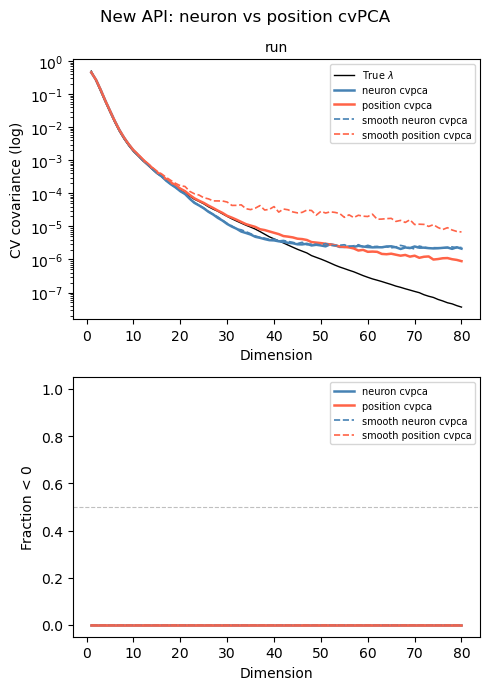

In [242]:
print(f"Running {N_SIMS} simulations (generator={type(NEW_ACTIVE_CFG.generator).__name__})...")
new_base_result = run_neuron_position(NEW_ACTIVE_CFG, n_sims=N_SIMS, device=DEVICE)
print(f"  burn_in={new_base_result['burn_in']}")
for key, label in [("frac_neg_cov_neuron", "neuron  "), ("frac_neg_cov_position", "position")]:
    fn = new_base_result[key]
    d40, d79 = min(39, len(fn) - 1), min(78, len(fn) - 1)
    print(f"  {label} frac<0 @dim{d40+1}/dim{d79+1}: {fn[d40]:.2f} / {fn[d79]:.2f}")
plot_neuron_position({"run": new_base_result}, suptitle="New API: neuron vs position cvPCA")
plt.show()

## Section 2: rCVPCA vs stimspace — Optuna study

In [244]:
N_TRIALS = 200
N_SIMS_PER_TRIAL = 20
OPTUNA_SEED = 0

print(f"Running Optuna study: {N_TRIALS} trials x {N_SIMS_PER_TRIAL} sims  generator={type(NEW_ACTIVE_CFG.generator).__name__}")
new_study = run_study(NEW_ACTIVE_CFG, n_trials=N_TRIALS, n_sims_per_trial=N_SIMS_PER_TRIAL, device=DEVICE, seed=OPTUNA_SEED)
print_best_configs(new_study, top_n=5)

Running Optuna study: 200 trials x 20 sims  generator=TilburyConfig


  0%|          | 0/200 [00:00<?, ?it/s]

c:\Users\Andrew\Documents\GitHub\vrAnalysis\dimilibi\helpers.py:429: RuntimeWarning:

invalid value encountered in log




=== Top 5 configs by alpha_cvpca/alpha_stim ratio ===
#1  ratio=8.9207  trial=192  alpha_cvpca=5.791  alpha_stim=0.640
    amp_m=9.96  amp_s=0.06  A2_beta=21.97  sep=28.79
    sig_m=14.20  sig_s=0.20  sig_asym=0.33  p_m=2.08
    rep_a=0.53  rep_ls=1.67  rep_thr=0.5  noise=0.092  smooth=None  norm=True  center=True
#2  ratio=8.1058  trial=195  alpha_cvpca=6.016  alpha_stim=0.529
    amp_m=11.21  amp_s=0.05  A2_beta=22.43  sep=28.92
    sig_m=14.69  sig_s=0.21  sig_asym=0.32  p_m=2.10
    rep_a=0.53  rep_ls=1.53  rep_thr=0.5  noise=0.174  smooth=None  norm=True  center=True
#3  ratio=7.8480  trial=199  alpha_cvpca=6.895  alpha_stim=0.885
    amp_m=14.68  amp_s=0.01  A2_beta=22.66  sep=29.30
    sig_m=14.60  sig_s=0.24  sig_asym=0.32  p_m=2.09
    rep_a=0.51  rep_ls=1.45  rep_thr=0.5  noise=0.352  smooth=None  norm=False  center=True
#4  ratio=7.8154  trial=198  alpha_cvpca=6.837  alpha_stim=0.841
    amp_m=13.73  amp_s=0.02  A2_beta=22.25  sep=29.64
    sig_m=14.56  sig_s=0.24  sig_asym

In [245]:
new_figs = plot_study(new_study)
new_figs["history"].show()
new_figs["parallel"].show()

In [ ]:
new_cfg_best = config_from_params(new_study.best_trial.params, NEW_ACTIVE_CFG)
print(f"Best config  ratio={new_study.best_trial.value:.4f}  generator={type(new_cfg_best.generator).__name__}")
for k, v in new_study.best_trial.params.items():
    print(f"  {k}={v}")

new_stacked = run_cvpca_stimspace_stack(new_cfg_best, n_sims=N_SIMS, device=DEVICE)
print(f"\nMedian ratio:    {np.median(new_stacked['ratio']):.3f}")
print(f"Mean ratio:      {new_stacked['ratio'].mean():.3f} +/- {new_stacked['ratio'].std():.3f}")
print(f"Mean alpha_cv:   {new_stacked['alpha_cvpca'].mean():.3f}")
print(f"Mean alpha_stim: {new_stacked['alpha_stim'].mean():.3f}")

In [ ]:
plot_spectra(new_cfg_best, n_sims=N_SIMS, device=DEVICE)
plt.show()

plot_frac_neg(new_stacked)
plt.show()

plot_placefields(new_cfg_best, device=DEVICE)
plt.show()

plot_component_alignment(new_stacked, n_show=80)
plt.show()

## Section 3: Multi-config comparison (uses NEW_COMPARE_CFGS)

In [ ]:
new_compare_stacked = {}
for label, cfg in NEW_COMPARE_CFGS.items():
    print(f"Running '{label}'  generator={type(cfg.generator).__name__}...")
    new_compare_stacked[label] = run_cvpca_stimspace_stack(cfg, n_sims=N_SIMS, device=DEVICE)
    s = new_compare_stacked[label]
    print(f"  median_ratio={np.median(s['ratio']):.3f}  alpha_cv={s['alpha_cvpca'].mean():.3f}  alpha_stim={s['alpha_stim'].mean():.3f}")

In [ ]:
for label, cfg in NEW_COMPARE_CFGS.items():
    fig = plot_spectra(cfg, n_sims=N_SIMS, device=DEVICE)
    fig.suptitle(f"{label}  ({type(cfg.generator).__name__})", fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
for label, cfg in NEW_COMPARE_CFGS.items():
    fig = plot_placefields(cfg, device=DEVICE)
    fig.suptitle(label, fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
fig, axes = plt.subplots(1, len(new_compare_stacked), figsize=(5 * len(new_compare_stacked), 4), squeeze=False)
for ax, (label, s) in zip(axes[0], new_compare_stacked.items()):
    n_comp = s["reg_cov"].shape[1]
    dims = np.arange(1, n_comp + 1)
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.plot(dims, s["frac_neg_reg_cov"], color="steelblue", lw=1.8, label="rCVPCA")
    ax.plot(dims, s["frac_neg_cv_var_raw"], color="tomato", lw=1.8, label="stimspace")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Dimension")
    ax.legend(fontsize=8)
axes[0][0].set_ylabel("Fraction < 0")
plt.suptitle("Fraction negative per component", fontsize=11)
plt.tight_layout()
plt.show()